In [1]:
%reload_ext autoreload
%autoreload 2

# Imports

In [2]:
from kret_notebook import *  # NOTE import first
from kret_lgbm._core.lgbm_nb_imports import *
from kret_lightning._core.lightning_nb_imports import *
from kret_matplotlib._core.mpl_nb_imports import *
from kret_np_pd._core.np_pd_nb_imports import *
from kret_optuna._core.optuna_nb_imports import *
from kret_polars._core.polars_nb_imports import *
from kret_rosetta._core.rosetta_nb_imports import *
from kret_sklearn._core.sklearn_nb_imports import *
from kret_torch_utils._core.torch_nb_imports import *
from kret_tqdm._core.tqdm_nb_imports import *
from kret_type_hints._core.types_nb_imports import *
from kret_utils._core.utils_nb_imports import *

# from kret_wandb._core.wandb_nb_imports import *  # NOTE this is slow to import

Loaded environment variables from /Users/Akseldkw/coding/Columbia/NBA-Timeout-Impact/.env
[kret_lgbm._core.lgbm_nb_imports] Imported kret_lgbm._core.lgbm_nb_imports in 2.2315 seconds
[kret_lightning._core.lightning_nb_imports] Imported kret_lightning._core.lightning_nb_imports in 4.0785 seconds
[kret_matplotlib._core.mpl_nb_imports] Imported kret_matplotlib._core.mpl_nb_imports in 0.2781 seconds
[kret_np_pd._core.np_pd_nb_imports] Imported kret_np_pd._core.np_pd_nb_imports in 0.0017 seconds
[kret_optuna._core.optuna_nb_imports] Imported kret_optuna._core.optuna_nb_imports in 0.0007 seconds
[kret_polars._core.polars_nb_imports] Imported kret_polars._core.polars_nb_imports in 0.0811 seconds
[kret_rosetta._core.rosetta_nb_imports] Imported kret_rosetta._core.rosetta_nb_imports in 0.0000 seconds
[kret_sklearn._core.sklearn_nb_imports] Imported kret_sklearn._core.sklearn_nb_imports in 0.1802 seconds
[kret_torch_utils._core.torch_nb_imports] Imported kret_torch_utils._core.torch_nb_imports i

In [3]:
from nba_timeout_impact.load_data_utils import NBADataLoader
from nba_timeout_impact.clean_pipeline import NBAStatsV3CleanPipeline
from nba_timeout_impact.constants import NBAConstants
from nba_timeout_impact.nba_dataset import NBADataset, NBAMemoDF, NBADatasetInput_TypedDict

# Load Data

In [4]:
# NBA_DATA_DIR = NBAConstants.NBA_DATA_DIR
# nba = pd.read_parquet(NBA_DATA_DIR / "nba_statsv3_clean.parquet")
# UKS_NP_PD.dtt([nba], how="head", filter=nba.IsPlayoff)

In [5]:
nba = NBADataset.load_from_parquet()

Validating data...


# Implementation

In [6]:
nba_memo = NBAMemoDF({"data": nba})

In [7]:
gameid = 20000018
f_gameid = nba_memo.data.gameId == gameid

In [8]:
UKS_NP_PD.dtt([nba_memo.data], filter=f_gameid, show_dims=True, n=10, how=(460, 475))

,game_date_ffill,gameId,actionId,actionType,subType,scoreHome,scoreAway,pointsTotal,period,game_seconds_elapsed,seconds_remaining,seconds_elapsed,teamTricode,shotResult,isFieldGoal,location,description,shotValue,IsPlayoff,game_date,playerNameI,actionNumber,clock,teamId,personId,playerName,xLegacy,yLegacy,shotDistance,videoAvailable
,datetime64[ms],int64,int64,category,category,int64,int64,int64,int64,float64,float64,float64,category,category,int64,category,str,float64,bool,datetime64[ms],category,int64,str,int64,int64,category,int64,int64,int64,int64
2205084,2000-11-01,20000018,461,Substitution,NaN,86,88,174,4,2876.100,3.900,716.100,CLE,NaN,0,h,SUB: Person FOR Weatherspoon,NaN,False,2000-11-01,C. Weatherspoon,481,PT00M03.90S,1610612739,221,Weatherspoon,0,0,0,0
2205085,2000-11-01,20000018,462,Substitution,NaN,86,88,174,4,2876.100,3.900,716.100,SAC,NaN,0,v,SUB: Barry FOR Pollard,NaN,False,2000-11-01,S. Pollard,482,PT00M03.90S,1610612758,1513,Pollard,0,0,0,0
2205086,2000-11-01,20000018,463,Missed Shot,Jump Shot,86,88,174,4,2879.700,0.300,719.700,CLE,Missed,1,h,MISS Murray 23' Jump Shot,NaN,False,2000-11-01,L. Murray,483,PT00M00.30S,1610612739,441,Murray,-191,127,23,0
2205087,2000-11-01,20000018,464,Rebound,Unknown,86,88,174,4,2879.800,0.200,719.800,CLE,NaN,0,h,Person REBOUND (Off:2 Def:3),NaN,False,2000-11-01,W. Person,485,PT00M00.20S,1610612739,445,Person,0,0,0,0
2205088,2000-11-01,20000018,465,Made Shot,Tip Shot,88,88,176,4,2879.900,0.100,719.900,CLE,Made,1,h,Person 1' Tip Shot (6 PTS),NaN,False,2000-11-01,W. Person,484,PT00M00.10S,1610612739,445,Person,-4,7,1,0
2205089,2000-11-01,20000018,466,period,end,88,88,176,4,2880.000,0.000,720.000,NaN,NaN,0,NaN,End of 4th Period (1:56 PM EST),NaN,False,2000-11-01,NaN,486,PT00M00.00S,0,0,NaN,0,0,0,0
2205090,2000-11-01,20000018,467,period,start,88,88,176,5,2880.000,300.000,0.000,NaN,NaN,0,NaN,Start of 1st OT (1:58 PM EST),NaN,False,2000-11-01,NaN,488,PT05M00.00S,0,0,NaN,0,0,0,0
2205091,2000-11-01,20000018,468,Jump Ball,NaN,88,88,176,5,2880.000,300.000,0.000,CLE,NaN,0,h,Jump Ball Ilgauskas vs. Webber: Tip to Weatherspoon,NaN,False,2000-11-01,Z. Ilgauskas,489,PT05M00.00S,1610612739,980,Ilgauskas,0,0,0,0
2205092,2000-11-01,20000018,469,Turnover,Offensive Goaltending,88,88,176,5,2905.000,275.000,25.000,CLE,NaN,0,h,Ilgauskas Offensive Goaltending Turnover (P3.T20),NaN,False,2000-11-01,Z. Ilgauskas,492,PT04M35.00S,1610612739,980,Ilgauskas,0,0,0,0


In [9]:
UKS_NP_PD.dtt(nba_memo.data, how="tail")

,game_date_ffill,gameId,actionId,actionType,subType,scoreHome,scoreAway,pointsTotal,period,game_seconds_elapsed,seconds_remaining,seconds_elapsed,teamTricode,shotResult,isFieldGoal,location,description,shotValue,IsPlayoff,game_date,playerNameI,actionNumber,clock,teamId,personId,playerName,xLegacy,yLegacy,shotDistance,videoAvailable
,datetime64[ms],int64,int64,category,category,int64,int64,int64,int64,float64,float64,float64,category,category,int64,category,str,float64,bool,datetime64[ms],category,int64,str,int64,int64,category,int64,int64,int64,int64
18049798,2025-06-22,42400407,538,NaN,NaN,103,89,192,4,2860.100,19.900,700.100,IND,NaN,0,v,Mathurin STEAL (2 STL),0.000,True,2025-06-22,B. Mathurin,755,PT00M19.90S,1610612754,1631097,Mathurin,0,0,0,1
18049799,2025-06-22,42400407,539,Foul,Shooting,103,89,192,4,2860.500,19.500,700.500,OKC,NaN,0,h,Jones S.FOUL (P1.PN) (S.Wright),0.000,True,2025-06-22,D. Jones,757,PT00M19.50S,1610612760,1641794,Jones,0,0,0,1
18049800,2025-06-22,42400407,540,Free Throw,Free Throw 1 of 2,103,90,193,4,2860.500,19.500,700.500,IND,NaN,0,v,Mathurin Free Throw 1 of 2 (23 PTS),0.000,True,2025-06-22,B. Mathurin,759,PT00M19.50S,1610612754,1631097,Mathurin,0,0,0,1
18049801,2025-06-22,42400407,541,Free Throw,Free Throw 2 of 2,103,91,194,4,2860.500,19.500,700.500,IND,NaN,0,v,Mathurin Free Throw 2 of 2 (24 PTS),0.000,True,2025-06-22,B. Mathurin,760,PT00M19.50S,1610612754,1631097,Mathurin,0,0,0,1
18049802,2025-06-22,42400407,542,period,end,103,91,194,4,2880.000,0.000,720.000,NaN,NaN,0,NaN,End of 4th Period (10:49 PM EST),0.000,True,2025-06-22,NaN,761,PT00M00.00S,0,0,NaN,0,0,0,1


Calculating lead


<Axes: >

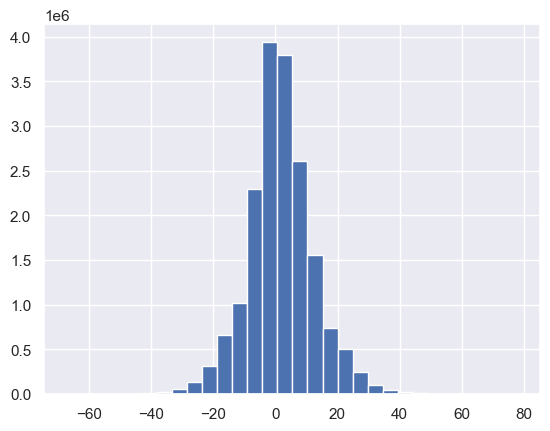

In [10]:
pd.Series(nba_memo.lead).hist(bins=30)

# Sandbox

In [ ]:
ptr_1_min = nba_memo.ptr_n_minutes(1)

In [ ]:
ptr_2_min = nba_memo.ptr_n_minutes(2)

In [ ]:
# nba_memo = NBAMemoDF({"data": nba})

In [13]:
nba_memo.data_sorted_time_elapsed

,gameId,game_seconds_elapsed,ptr,target_time
0,29600001,0.0,0,60.0
17802003,22400784,0.0,17802003,60.0
17802002,22400784,0.0,17802002,60.0
2653394,20000956,0.0,2653394,60.0
2653395,20000956,0.0,2653395,60.0
...,...,...,...,...
9296792,21100722,4080.0,9296792,4140.0
9296791,21100722,4080.0,9296791,4140.0
13712621,21800928,4080.0,13712621,4140.0
11530927,21500391,4080.0,11530927,4140.0


In [ ]:
ptr_2_min = nba_memo.ptr_n_minutes(2)

In [15]:
cols = ["points", "score", "action", "shot", "lead", "streak", "f_", "game"]
cols_min = ["points", "score", "action", "game", "lead"]

In [28]:
UKS_NP_PD.dtt(
    [
        nba.col_filter(include=cols_min),
        nba_memo.lead,
        nba_memo.lead_change_n_minutes(1),
        nba.col_filter(include=cols_min).iloc[ptr_1_min],
        # nba.col_filter(include=cols_min).iloc[ptr_2_min],
    ],
    # filter=nba_memo.f_streak_12,
    num_cols=3,
    n=3,
    # how=(50, 70),
    how="head",
    # slice=(0,20),
    show_dims=True,
)

Returning df without 20 columns: ['subType', 'period', 'seconds_remaining', 'seconds_elapsed', 'teamTricode', 'shotResult', 'isFieldGoal', 'location', 'description', 'shotValue', 'IsPlayoff', 'playerNameI', 'clock', 'teamId', 'personId', 'playerName', 'xLegacy', 'yLegacy', 'shotDistance', 'videoAvailable']
Calculating lead_change_n_minutes(1,)
Returning df without 20 columns: ['subType', 'period', 'seconds_remaining', 'seconds_elapsed', 'teamTricode', 'shotResult', 'isFieldGoal', 'location', 'description', 'shotValue', 'IsPlayoff', 'playerNameI', 'clock', 'teamId', 'personId', 'playerName', 'xLegacy', 'yLegacy', 'shotDistance', 'videoAvailable']


game_date_ffill 
 gameId 
 actionId 
 actionType 
 scoreHome 
 scoreAway 
 pointsTotal 
 game_seconds_elapsed 
 game_date 
 actionNumber 
 
 
 
 datetime64[ms] 
 int64 
 int64 
 category 
 int64 
 int64 
 int64 
 float64 
 datetime64[ms] 
 int64 
 
 
 
 
 0 
 1996-11-01 
 29600001 
 1 
 period 
 0 
 0 
 0 
 0.000 
 1996-11-01 
 1 
 
 
 1 
 1996-11-01 
 29600001 
 2 
 Jump Ball 
 0 
 0 
 0 
 0.000 
 1996-11-01 
 2 
 
 
 2 
 1996-11-01 
 29600001 
 3 
 Made Shot 
 0 
 2 
 2 
 21.000 
 1996-11-01 
 4 
 
 
 
 Showing 3 of 18,049,803 rows × 10 columns 
 
 
 
 
 
 0 
 
 
 
 int64 
 
 
 
 
 0 
 0 
 
 
 1 
 0 
 
 
 2 
 -2 
 
 
 
 Showing 3 of 18,049,803 rows × 1 columns 
 
 
 
 
 
 0 
 
 
 
 int64 
 
 
 
 
 0 
 1 
 
 
 1 
 1 
 
 
 2 
 1 
 
 
 
 Showing 3 of 18,049,803 rows × 1 columns 
 
 
 
 
 
 game_date_ffill 
 gameId 
 actionId 
 actionType 
 scoreHome 
 scoreAway 
 pointsTotal 
 game_seconds_elapsed 
 game_date 
 actionNumber 
 
 
 
 datetime64[ms] 
 int64 
 int64 
 category 
 int64 
 int64 
 int64 
 float64 
 datetime64[ms] 
 int64 
 
 
 
 
 8 
 1996-11-01 
 29600001 
 9 
 Made Shot 
 4 
 3 
 7 
 58.000 
 1996-11-01 
 8 
 
 
 8 
 1996-11-01 
 29600001 
 9 
 Made Shot 
 4 
 3 
 7 
 58.000 
 1996-11-01 
 8 
 
 
 9 
 1996-11-01 
 29600001 
 10 
 Made Shot 
 4 
 5 
 9 
 74.000 
 1996-11-01 
 9 
 
 
 
 Showing 3 of 18,049,803 rows × 10 columns

In [79]:
UKS_NP_PD.dtt(
    [
        # UKS_NP_PD.col_filter(nba, include=cols),
        nba.col_filter(include=cols),
        # UKS_NP_PD.col_filter(nba_memo.to_pandas(), include=cols),
        nba_memo.to_pandas_memo(),
        # out,
    ],
    filter=nba_memo.f_streak_12,
    n=21,
    # how=(50, 70),
    how="head",
    # slice=(0,20),
    show_dims=True,
)

Returning df without 17 columns: ['subType', 'period', 'seconds_remaining', 'seconds_elapsed', 'teamTricode', 'isFieldGoal', 'location', 'description', 'IsPlayoff', 'playerNameI', 'clock', 'teamId', 'personId', 'playerName', 'xLegacy', 'yLegacy', 'videoAvailable']


,game_date_ffill,gameId,actionId,actionType,scoreHome,scoreAway,pointsTotal,game_seconds_elapsed,shotResult,shotValue,game_date,actionNumber,shotDistance
,datetime64[ms],int64,int64,category,int64,int64,int64,float64,category,float64,datetime64[ms],int64,int64
159,1996-11-01,29600001,160,Made Shot,45,33,78,992.000,Made,NaN,1996-11-01,148,0
160,1996-11-01,29600001,161,Foul,45,33,78,992.000,NaN,NaN,1996-11-01,149,0
161,1996-11-01,29600001,162,Substitution,45,33,78,992.000,NaN,NaN,1996-11-01,151,0
162,1996-11-01,29600001,163,Free Throw,46,33,79,992.000,NaN,NaN,1996-11-01,152,0
163,1996-11-01,29600001,164,Missed Shot,46,33,79,1005.000,Missed,NaN,1996-11-01,153,0
164,1996-11-01,29600001,165,Rebound,46,33,79,1007.000,NaN,NaN,1996-11-01,154,0
165,1996-11-01,29600001,166,Made Shot,49,33,82,1029.000,Made,NaN,1996-11-01,155,0
166,1996-11-01,29600001,167,Timeout,49,33,82,1051.000,NaN,NaN,1996-11-01,156,0
167,1996-11-01,29600001,168,Substitution,49,33,82,1051.000,NaN,NaN,1996-11-01,158,0
